In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl


# Path to your CSV folder (adjust this to where your files are stored)
csv_folder = "data/mnist-in-csv"
n_train = 1000

visualise = False
boundary_only = True
connected_paths = True
path_type = 'pca'  # 'raw' or 'pca'
path_length = 'direct'  # 'direct' or 'local'


In [562]:

def plot_paths(images, labels, indices):
    
    # 4. Plot them
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        plt.subplot(5, 5, i + 1)
        x = images[idx].reshape(28, 28)  # reshape to 28x28
        plt.imshow(x, cmap="gray")  # grayscale for MNIST
        plt.title(f"Index {idx}")

        plt.xticks([])   # remove tick labels, keep axis
        plt.yticks([])
        plt.xlabel(f"Label: {labels[idx]}")

    plt.tight_layout()
    plt.show()



def stratified_subsample(X, y, n_samples, random_state=42):
    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        train_size=n_samples,
        stratify=y,
        random_state=random_state
    )
    return X_sub, y_sub


def load_mnist_data(csv_path, n_samples=None):
    # Load MNIST from CSV (assuming first column is label, rest are pixels)
    df = pd.read_csv(csv_path, dtype=np.uint8)
    X = df.iloc[:, 1:]/255
    X = X.astype("float32")

    # X = df.iloc[:, 1:].values.astype(np.float32)
    
    y = df.iloc[:, 0].values  

    # Subsample if n_samples is specified
    if n_samples is not None:
        if n_samples > X.shape[0]:
            raise ValueError(f"n_samples {n_samples} exceeds dataset size {X.shape[0]}")

        X, y = stratified_subsample(X, y, n_samples)
    
    return X, y



Load test and train full datasets

In [563]:

# List all CSV files in the folder
csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

# Read all CSVs into a dictionary of DataFrames
dataframes = {file: pd.read_csv(os.path.join(csv_folder, file)) for file in csv_files}

# Example: show basic info for each file
for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    print(df.head())      # first 5 rows
    print(df.info())      # column details



--- mnist_train.csv ---
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
me

In [564]:
# number_of_samples = 10000
X,y = load_mnist_data("data/mnist-in-csv/mnist_train.csv",
                           n_samples=10000)

# X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

X_test = dataframes['mnist_test.csv'].drop(columns=["label"])  # everything except the target
y_test = dataframes['mnist_test.csv']["label"]  # everything except the

X_test, X_dev, y_test, y_dev = train_test_split(X_test, y_test, test_size=0.5, random_state=42,shuffle=True)

In [565]:
# y_train_df = pd.DataFrame(index=X_train.index)
# y_train_df['y'] = y_train

y_df = pd.DataFrame(index=X.index)
y_df['y'] = y


In [566]:
raw_paths  = pd.read_csv("data/paths/mnist_paths_space-raw_k-20_paths-100000_datasize-10000.csv")
pca_paths  = pd.read_csv("data/paths/mnist_paths_space-pca_k-20_paths-100000_datasize-10000.csv")
face_paths = pd.read_csv("data/paths/mnist_paths_FACE_paths-70000_datasize-10000.csv")
face_paths['path_id'] = face_paths['path_id'].str.replace('_to', '', regex=False)

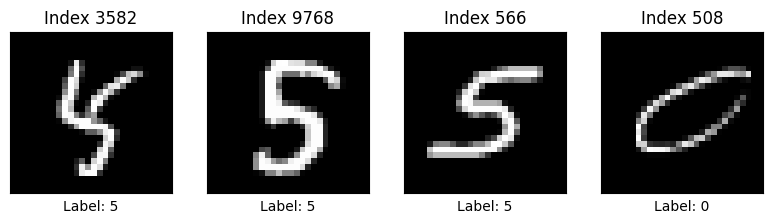

In [567]:
face_subset = face_paths.iloc[0:3]
plot_paths(np.array(X),list(y),list(face_subset['index'])+[508])

In [568]:
raw_demo_path = raw_paths.iloc[0:4]
pca_demo_path = pca_paths.iloc[0:8]
face_demo_path = face_paths.iloc[0:3]

In [569]:
raw_demo_path.head()

,index,next_index,path_id,start_label,end_label
0,1020,865,1020_9857,6,5
1,865,6346,1020_9857,6,5
2,6346,2877,1020_9857,6,5
3,2877,9857,1020_9857,6,5


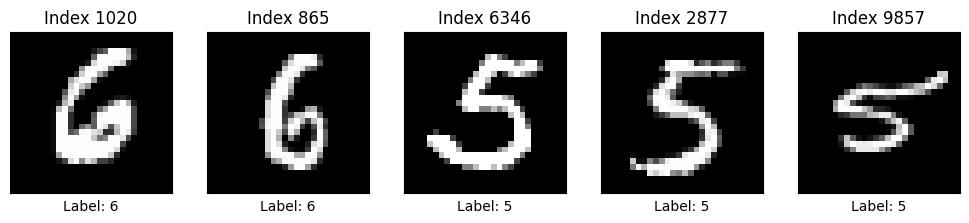

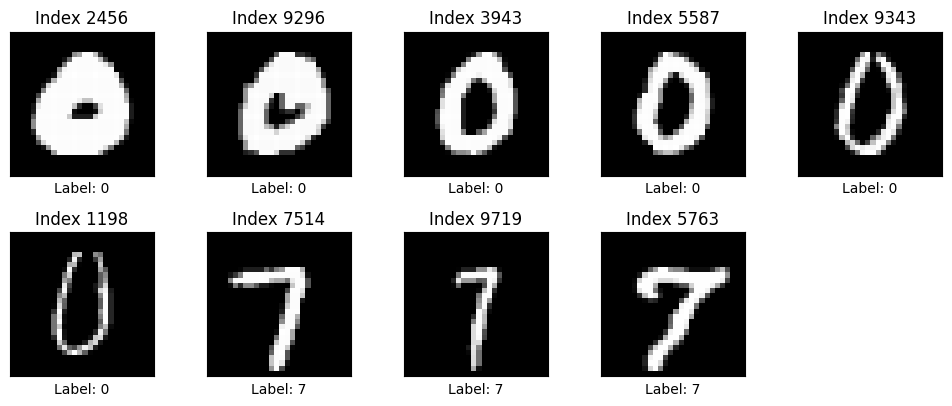

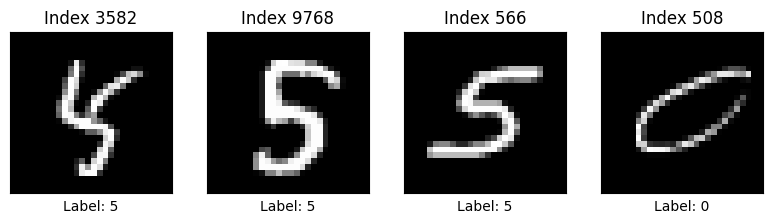

In [570]:
for demo_path in [raw_demo_path,pca_demo_path,face_demo_path]:
    indices = list(demo_path['index'])
    final_ind = list([demo_path['next_index'].iloc[-1]])
    
    plot_paths(np.array(X),list(y),indices+final_ind)
    print

In [571]:
path_dict = {
    'raw': raw_paths,
    'pca': pca_paths,
    'face': face_paths
}


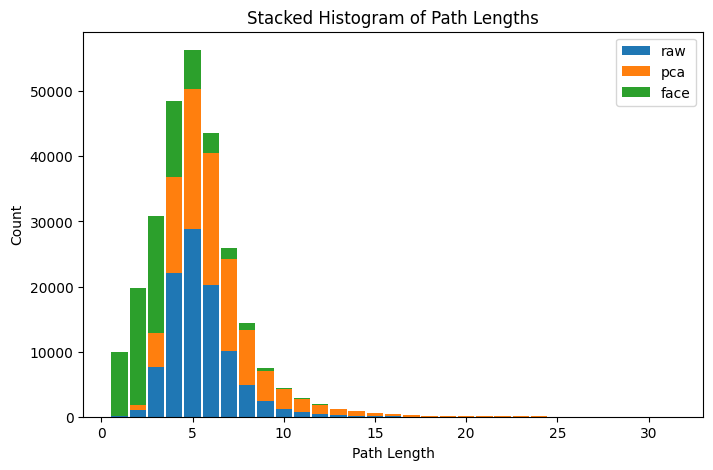

In [572]:
plt.figure(figsize=(8, 5))

all_lengths = [
    paths['path_id'].value_counts()
    for paths in path_dict.values()
]

labels = list(path_dict.keys())

plt.hist(all_lengths, 
         bins=range(1, max(max(l) for l in all_lengths) + 1),
         stacked=True,
         label=labels,
         align='left',
         rwidth=0.9)

plt.legend()
plt.xlabel("Path Length")
plt.ylabel("Count")
plt.title("Stacked Histogram of Path Lengths")
plt.show()


In [573]:
grouped_paths = face_paths.groupby('path_id')

In [574]:
import pandas as pd

def dedupe_variable_length_journeys(df, index_col="index", next_col="next_index"):
    """
    Deduplicate variable-length journeys defined by (index → next_index) chains.
    
    A journey is any contiguous chain where each row's `index` equals the
    previous row's `next_index`. Journeys can be any length.
    
    Returns only one copy of each unique journey sequence.
    Journeys with the same path but different sequences are all preserved.
    Journeys with identical sequences are collapsed into one.
    """
    
    # Ensure sorted by original order
    df = df.copy().sort_index()

    # 1. Identify where journeys break
    df["new_journey"] = df[index_col] != df[next_col].shift(1)
    df["journey_id_real"] = df["new_journey"].cumsum()

    # 2. Build canonical sequence signatures for each journey
    def make_signature(group):
        # A journey is represented as a tuple of pairs
        return tuple(zip(group[index_col], group[next_col]))

    signatures = df.groupby("journey_id_real").apply(make_signature)

    # 3. Keep only unique signatures (drop duplicate journeys)
    unique_journey_ids = signatures.drop_duplicates().index

    # 4. Filter original dataframe to only those journeys
    result = df[df["journey_id_real"].isin(unique_journey_ids)].copy()

    # Cleanup optional:
    result.drop(columns=["new_journey"], inplace=True)

    return result


In [575]:
result = dedupe_variable_length_journeys(face_paths)

/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_51208/713788841.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  signatures = df.groupby("journey_id_real").apply(make_signature)


In [576]:
testdf = raw_paths[raw_paths['path_id']=='5852_3541'].copy()

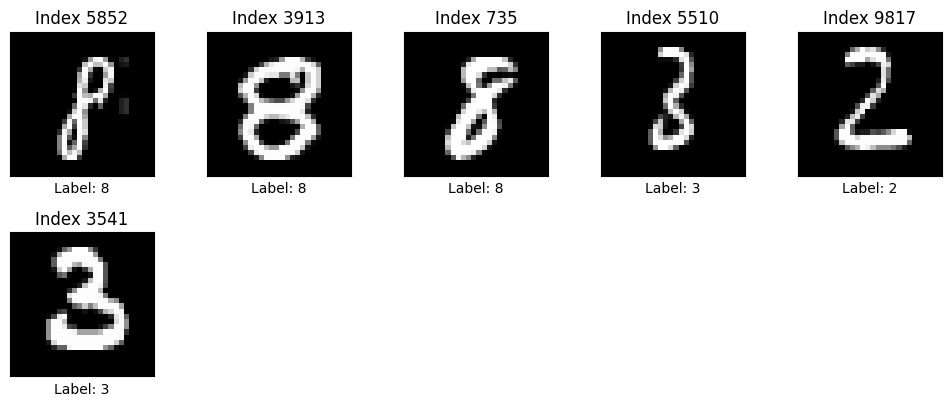

In [577]:
y[testdf['index'].values]

indices = list(testdf['index'].values)
final_ind = list([testdf['next_index'].values[-1]])

plot_paths(np.array(X),list(y),indices+final_ind)

In [578]:
for paths in path_dict.values():
    print(len(set(paths['path_id'])))


100000
100000
70001


In [579]:
from tqdm import tqdm
import math

from random import sample, seed

random_seed = 42
seed(random_seed)

path_dict = {
    'raw': raw_paths,
    'pca': pca_paths,
    'face': result,
}

data_dict ={}

common_path_ids = set.intersection(*[
    set([p_id.split("_")[0] for p_id in paths['path_id']])
    for paths in path_dict.values()
])

x_sample = sample(list(common_path_ids),n_train)

sample_path_ids = {}


In [580]:

for path_name,paths in path_dict.items():

    sample_path_ids[path_name] = [sample([p for p in paths['path_id'].unique() if p.split("_")[0] == x],1)[0] for x in x_sample]

    data_dict[path_name] = {
    'X':[],
    'Y':[],
    'K':{
        'X':[],
        'Y':[],
        'K':[],
        }
    }   

    print("Path Type: ",path_name)
    both_ways = False
    # path_ids = [ p for p in paths['path_id'].unique() if p.split("_")[0] in x_sample]
    

    for path_id in tqdm(sample_path_ids[path_name]): #sample(list(path_ids),int(math.floor(n_train/2)))):
        X_0,X_1 = [int(id) for id in path_id.split("_")]
        Y_0,Y_1 = y[int(X_0)],y[int(X_1)]
        
        paths_subset = paths[paths['path_id']==path_id].copy()
        
        full_path = list(paths_subset['index'].values) + [paths_subset['next_index'].values[-1]]

        # print("Full Path & Label:")
        # for pair in list(zip(full_path,[y[index] for index in full_path])):
        #     print(f"    {pair}")
        
        """
        Change here for paths with multiple boundaries:
        # change_indice = np.where(y[full_path] == Y_1)[0][0]
        """ 
        change_indice = np.where(y[full_path] != Y_0)[0][0]
        # print('indices: ',full_path,
        #       '\nChange: ',change_indice,
        #       '\nLabel: ',[y[p] for p in full_path])


        Z0 = {
            'X':full_path[:change_indice],
            # 'Y':y_df.loc[paths_subset['index']]['y'],
            'Y':list(y[full_path])[:change_indice],
            'Y':y[full_path][:change_indice],
            'K':full_path[1:change_indice+1],
        }
        Z1 = {
            'X':full_path[change_indice:][::-1],
            # 'Y':y_df.loc[paths_subset['index']]['y'],
            'Y':list(y[full_path])[change_indice:][::-1],
            'K':full_path[change_indice-1:-1][::-1],
        }

        # print('X: ',X_0,X_1,
        #       '\nY: ',Y_0,Y_1,
        #       '\nK :',Z0
        #       )

        # path_data = {
        #     'X':[X_0,X_1],
        #     'Y':[Y_0,Y_1],
        #     'Z':{
        #         'X':[Z0['X'],Z1['X']],
        #         'Y':[Z0['Y'],Z1['Y']],
        #         'K':[Z0['K'],Z1['K']],
        #     }
        # }

        if both_ways:
            data_dict[path_name]['X'].extend([X_0, X_1])
            data_dict[path_name]['Y'].extend([Y_0, Y_1])

            data_dict[path_name]['K']['X'].append(Z0['X'])
            data_dict[path_name]['K']['X'].append(Z1['X'])

            data_dict[path_name]['K']['Y'].append(Z0['Y'])
            data_dict[path_name]['K']['Y'].append(Z1['Y'])

            data_dict[path_name]['K']['K'].append(Z0['K'])
            data_dict[path_name]['K']['K'].append(Z1['K'])
        else:
            data_dict[path_name]['X'].append(X_0)
            data_dict[path_name]['Y'].append(Y_0)

            data_dict[path_name]['K']['X'].append(Z0['X'])
            data_dict[path_name]['K']['Y'].append(Z0['Y'])
            data_dict[path_name]['K']['K'].append(Z0['K'])


        
        

Path Type:  raw


100%|██████████| 100/100 [00:02<00:00, 49.64it/s]


Path Type:  pca


100%|██████████| 100/100 [00:02<00:00, 42.87it/s]


Path Type:  face


100%|██████████| 100/100 [00:00<00:00, 120.04it/s]


In [581]:
assert data_dict['raw']['X'] == data_dict['pca']['X']
assert data_dict['raw']['Y'] == data_dict['pca']['Y']
assert data_dict['raw']['X'] == data_dict['face']['X']


In [582]:
import pickle as pkl

with open(f'data/paths/mnist_paths_data_split_{n_train}paths.pkl', 'wb') as f:
    pkl.dump(data_dict, f)  

In [583]:
n_train

100

In [584]:
raw_paths

,index,next_index,path_id,start_label,end_label
0,1020,865,1020_9857,6,5
1,865,6346,1020_9857,6,5
2,6346,2877,1020_9857,6,5
3,2877,9857,1020_9857,6,5
4,5852,3913,5852_3541,8,3
...,...,...,...,...,...
541151,2450,7654,8725_6751,0,7
541152,7654,7581,8725_6751,0,7
541153,7581,7888,8725_6751,0,7
541154,7888,5332,8725_6751,0,7


In [585]:
paths = {
    'raw':{'original':{'inputs':raw_paths}},
    'pca':{'original':{'inputs':pca_paths}},
    'face':{'original':{'inputs':face_paths}}
}

for path_type, path in paths.items():
    paths[path_type]['split'] = {'outputs': data_dict[path_type]}
    
    print(f"{path_type} paths, Split: {len(paths[path_type]['split']['outputs'])}")


raw paths, Split: 3
pca paths, Split: 3
face paths, Split: 3


In [586]:
def compile_mnist(X,y,cf_X,cf_y):

    magnitude = np.ones(len(cf_X))
    magnitude = np.expand_dims(magnitude, axis=1)
    
    print(f'Returning {len(X)} samples with {len(cf_y)} counterfactuals')
    
    return {'X':np.array(X),
            'Y':list(y),
            'K':{
                'vector':cf_X,
                 'label':cf_y,
                 'magnitude':np.expand_dims(magnitude,axis=1), 
                 }}

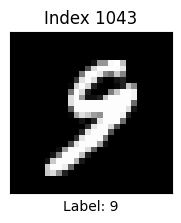

[9 9]


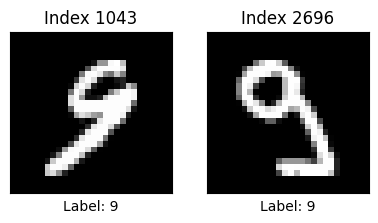

Y [2 2]


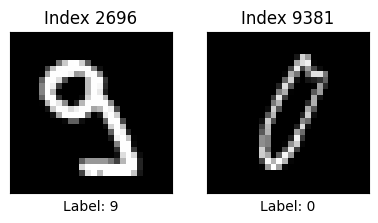

In [587]:
dset = paths['face']['split']['outputs']

plot_paths(np.array(X),list(y),[dset['X'][0]])
print(dset['K']['Y'][0])
plot_paths(np.array(X),list(y),dset['K']['X'][0])
print('Y',[y[i] for i in dset['K']['Y']][0])

plot_paths(np.array(X),list(y),dset['K']['K'][0])

In [588]:
COMMON = True

for path_type, path in data_dict.items():
    print(f"Compiling {path_type} data split...")
    
    dataset = paths[path_type]['split']['outputs']

    if boundary_only:
        for key,val in dataset['K'].items():
            
            dataset['K'][key] = [v[-1:] for v in val]
    
    
    X_train_sample = np.array(X.iloc[dataset['X']])
    y_train_sample = np.array(dataset['Y']).squeeze()

    # Stripping html from unprocessed text, just to clean it up
    print('\ntrain_Data')
    cf_train={'original': {
                'X':np.array(X_train_sample),
                'Y':list(y_train_sample),
                'K':{
                    'X':[np.array(X.iloc[i]) for i in dataset['K']['X']],
                    # 'Y':[y[i] for i in dataset['K']['Y']],
                    'Y':dataset['K']['Y'],
                    'K':[np.array(X.iloc[i]) for i in dataset['K']['K']],
                    }}}
    # print([(x_i,y_i,k_i) for x_i,y_i,k_i in list(zip(dataset['K']['X'],dataset['K']['K'],dataset['K']['Y']))])
    # plot_paths(np.array(X),list(y),dataset['K']['X'][0])
    print('\ndev_Data')
    cf_dev={'original': {
                'X':np.array(X_dev),
                'Y':list(y_dev),
                'K':{
                    'X':np.array(np.zeros_like(X_dev)),
                    'Y':np.array(np.zeros_like(y_dev)),
                    'K':np.array(np.zeros_like(X_dev)),
                    }}}
    
            
    print('\ntest_Data')
    cf_test={'original': {
                'X':np.array(X_test),
                'Y':list(y_test),
                'K':{
                    'X':np.array(np.zeros_like(X_test)),
                    'Y':np.array(np.zeros_like(y_test)),
                    'K':np.array(np.zeros_like(X_test)),
                    }}}
    
    print('\ncontrol_Data')
    flattened_X = [x for xs in dataset['K']['X'] for x in xs]
    flattened_Y = [y for ys in dataset['K']['Y'] for y in ys]


    cf_control={'original': {
                'X':np.array(flattened_X),
                'Y':list(flattened_Y),
                'K':{
                    'X':np.array(np.zeros_like(flattened_X)),
                    'Y':np.array(np.zeros_like(flattened_Y)),
                    'K':np.array(np.zeros_like(flattened_X)),
                    }}}
    

    """
    ########################################################################################################################
    Save embeddings
    ########################################################################################################################
    """

    pickle_data = {'train':cf_train,'test':cf_test,'dev':cf_dev, 'control':cf_control,'n_classes': 10}
    
    embedding_path = f"data/integer_len{len(dataset['X'])}__connected_{str(connected_paths)}__path_{path_type}__split__boundary_{str(boundary_only)}.pkl"
    print(f"Saving to {embedding_path}")
    with open(embedding_path, 'wb') as file:
        pkl.dump(pickle_data, file)

    if visualise:
        print(f"PATH TYPE: {path_type} | PATH LENGTH: {path_length}")
        sample_size = 5
        # for i,K in enumerate(cf_train['original']['K']['X'][0:sample_size]):           
        for i in range(5):
            print(f'\n\nRow {i}')
            plot_paths(np.array(X),list(y),dataset['K']['X'][i])
            plot_paths(np.array(X),list(y),dataset['K']['K'][i]) 
            # plot_paths([cf_train['original']['X'][i]],[cf_train['original']['Y'][i]],[0])
            # plot_paths(K,cf_train['original']['K']['Y'][i],np.arange(len(K)))



Compiling raw data split...

train_Data

dev_Data

test_Data

control_Data
Saving to data/integer_len100__connected_True__path_raw__split__boundary_True.pkl
Compiling pca data split...

train_Data

dev_Data

test_Data

control_Data
Saving to data/integer_len100__connected_True__path_pca__split__boundary_True.pkl
Compiling face data split...

train_Data

dev_Data

test_Data

control_Data
Saving to data/integer_len100__connected_True__path_face__split__boundary_True.pkl


In [589]:
len(X)

10000

PATH TYPE: raw
Sample  38

X:


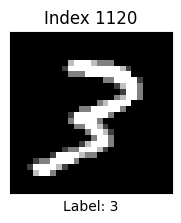


K Y: [3]

K X:


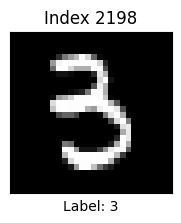


K K:


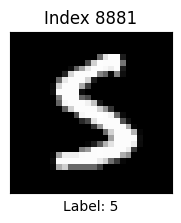

Sample  33

X:


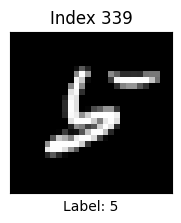


K Y: [5]

K X:


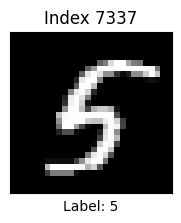


K K:


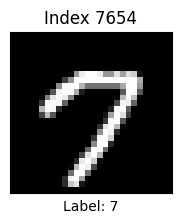

Sample  84

X:


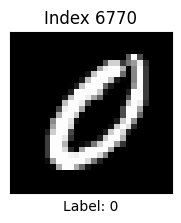


K Y: [0]

K X:


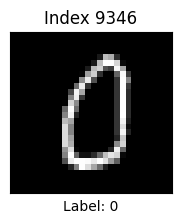


K K:


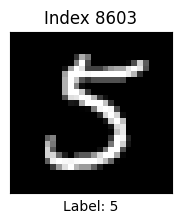

PATH TYPE: pca
Sample  38

X:


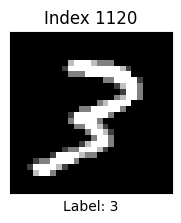


K Y: [3]

K X:


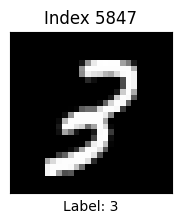


K K:


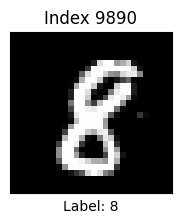

Sample  33

X:


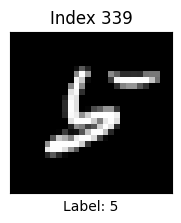


K Y: [5]

K X:


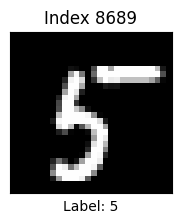


K K:


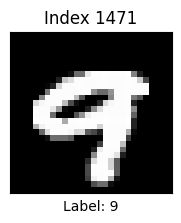

Sample  84

X:


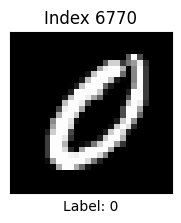


K Y: [0]

K X:


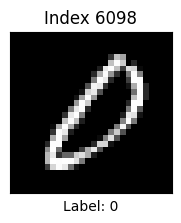


K K:


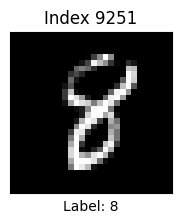

PATH TYPE: face
Sample  38

X:


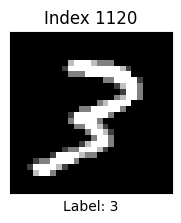


K Y: [3]

K X:


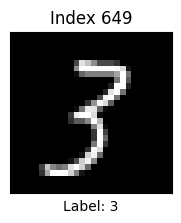


K K:


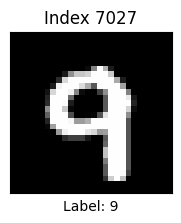

Sample  33

X:


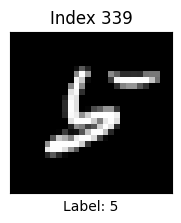


K Y: [5]

K X:


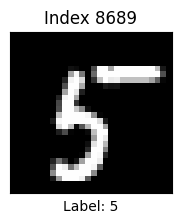


K K:


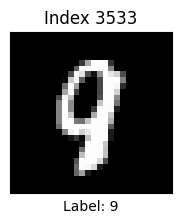

Sample  84

X:


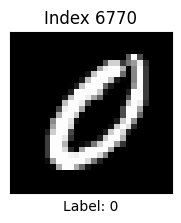


K Y: [0]

K X:


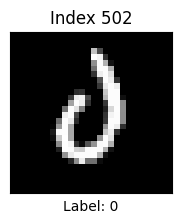


K K:


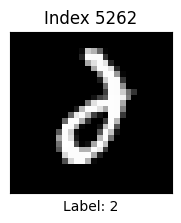

In [590]:
sample_list = np.random.choice(n_train,3,replace=False)
path_types = ['raw','pca','face']
for i,path_type in enumerate(path_types):
    print(f"PATH TYPE: {path_type}")
    dataset = paths[path_type]['split']['outputs']
    # print(f'\n\nRow {sample_list}')
    for j,s in enumerate(sample_list):
        print("Sample ",s)
        
        # indices = [dataset['X'][s]] + dataset['K']['X'][s] + dataset['K']['K'][s]
        # plot_paths(np.array(X),list(y),indices)
        print('\nX:')
        # indices = [dataset['X'][s]] +  + dataset['K']['K'][s]
        plot_paths(np.array(X),list(y),[dataset['X'][s]])
        print('\nK Y:',dataset['K']['Y'][s])
        print('\nK X:')
        plot_paths(np.array(X),list(y),dataset['K']['X'][s])
        print('\nK K:')
        plot_paths(np.array(X),list(y),dataset['K']['K'][s])
        # plot_paths(np.array(X),list(y),[dataset['X'][i]])
        # plot_paths(np.array(X),list(y),dataset['K']['X'][i])
        # plot_paths(np.array(X),list(y),dataset['K']['K'][i])

PATH TYPE: raw
Sample  61
[3]


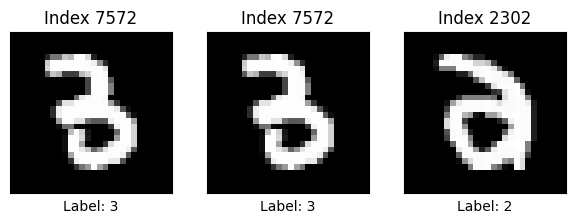

Sample  31
[0]


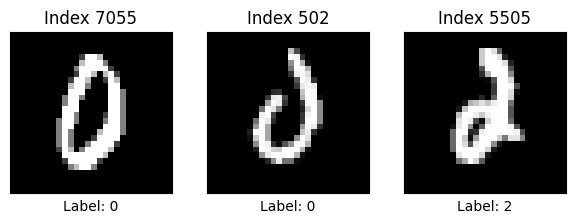

Sample  67
[1]


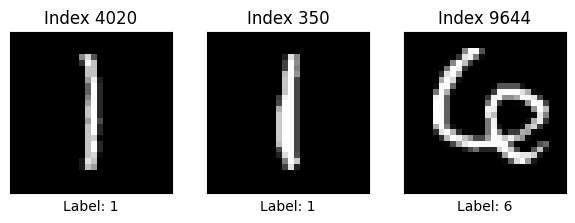

PATH TYPE: pca
Sample  61
[3]


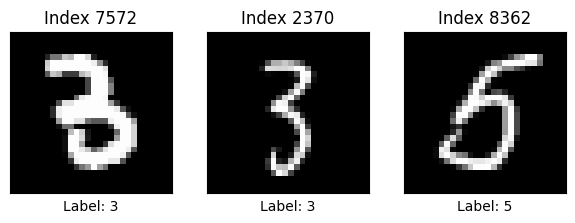

Sample  31
[0]


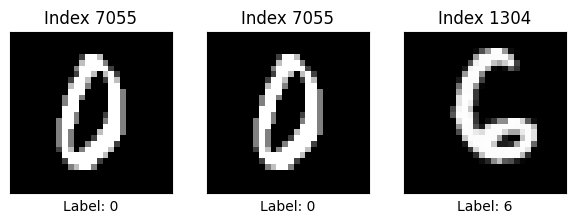

Sample  67
[1]


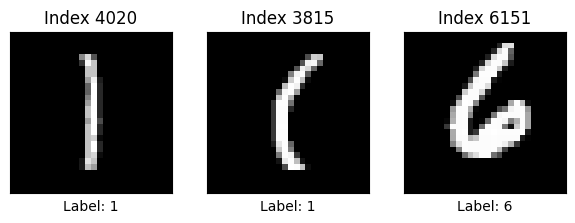

PATH TYPE: face
Sample  61
[3]


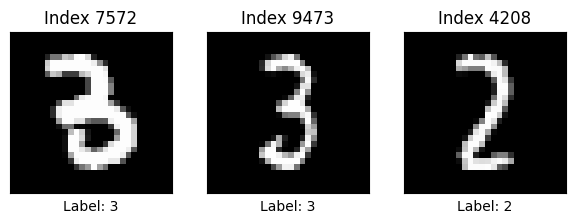

Sample  31
[0]


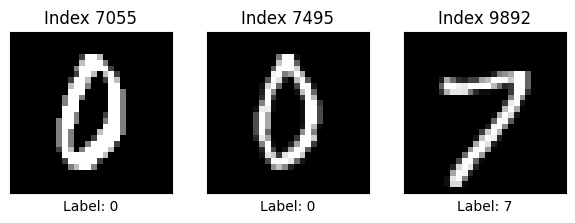

Sample  67
[1]


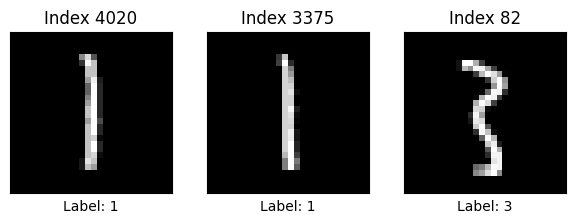

In [591]:
sample_list = np.random.choice(n_train,3,replace=False)
path_types = ['raw','pca','face']
for i,path_type in enumerate(path_types):
    print(f"PATH TYPE: {path_type}")
    dataset = paths[path_type]['split']['outputs']
    # print(f'\n\nRow {sample_list}')
    for j,s in enumerate(sample_list):
        print("Sample ",s)
        indices = [dataset['X'][s]] + dataset['K']['X'][s] + dataset['K']['K'][s]
        print(dataset['K']['Y'][s])
        plot_paths(np.array(X),list(y),indices)
        # plot_paths(np.array(X),list(y),[dataset['X'][i]])
        # plot_paths(np.array(X),list(y),dataset['K']['X'][i])
        # plot_paths(np.array(X),list(y),dataset['K']['K'][i])